#### Melakukan Analisis Menggunakan Python 
#### Analisis Data Patient Kanker Mata


Kanker mata merupakan penyakit yang disebabkan oleh sel perusak yang terjadi dibagian mata.
Data disediakan mengenai riwayat pasien, diagnosa pasien dan treatment pasien.f
Analisis data bertujuan untuk memberikan informasi mengenai kanker data.
Data bersifat informatif dan Data Dapat dipahami dengan mudah.

##### Pemanggilan library

In [4]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt 
import seaborn as sns



#### Mengimput data 

In [5]:
df=pd.read_csv("datasetEyeCancer.csv")
df.shape

(5000, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   baris                 5000 non-null   int64 
 1   Patient_ID            5000 non-null   object
 2   Age                   5000 non-null   int64 
 3   Gender                5000 non-null   object
 4   Cancer_Type           5000 non-null   object
 5   Laterality            5000 non-null   object
 6   Date_of_Diagnosis     5000 non-null   object
 7   Stage_at_Diagnosis    5000 non-null   object
 8   Treatment_Type        5000 non-null   object
 9   Surgery_Status        5000 non-null   bool  
 10  Radiation_Therapy     5000 non-null   int64 
 11  Chemotherapy          5000 non-null   int64 
 12  Outcome_Status        5000 non-null   object
 13  Survival_Time_Months  5000 non-null   int64 
 14  Genetic_Markers       5000 non-null   object
 15  Family_History        5000 non-null   

Keterangan dataframe :
data memiliki 5000 bari dan 18 columns


_______________


##### Cleaning dataframe

1. Pengecekan dan hapus/ganti nilai Null 
2. Pengecekan dan penghapusan data yang sama 
3. Transformasi judul columns
4. transformasi data dengan tipe objek 



1. Pengecekan dan hapus/ganto nilai null

In [7]:
df.isnull().sum ()

baris                   0
Patient_ID              0
Age                     0
Gender                  0
Cancer_Type             0
Laterality              0
Date_of_Diagnosis       0
Stage_at_Diagnosis      0
Treatment_Type          0
Surgery_Status          0
Radiation_Therapy       0
Chemotherapy            0
Outcome_Status          0
Survival_Time_Months    0
Genetic_Markers         0
Family_History          0
Country                 0
Year                    0
dtype: int64

2. Duplicate

In [8]:
df.duplicated().sum()

np.int64(0)

3. judul column

In [9]:
df.columns

Index(['baris', 'Patient_ID', 'Age', 'Gender', 'Cancer_Type', 'Laterality',
       'Date_of_Diagnosis', 'Stage_at_Diagnosis', 'Treatment_Type',
       'Surgery_Status', 'Radiation_Therapy', 'Chemotherapy', 'Outcome_Status',
       'Survival_Time_Months', 'Genetic_Markers', 'Family_History', 'Country',
       'Year'],
      dtype='object')

In [10]:
df.columns=df.columns.str.lower()
df.columns

Index(['baris', 'patient_id', 'age', 'gender', 'cancer_type', 'laterality',
       'date_of_diagnosis', 'stage_at_diagnosis', 'treatment_type',
       'surgery_status', 'radiation_therapy', 'chemotherapy', 'outcome_status',
       'survival_time_months', 'genetic_markers', 'family_history', 'country',
       'year'],
      dtype='object')

4. Ubah data object

In [11]:
df.columns

Index(['baris', 'patient_id', 'age', 'gender', 'cancer_type', 'laterality',
       'date_of_diagnosis', 'stage_at_diagnosis', 'treatment_type',
       'surgery_status', 'radiation_therapy', 'chemotherapy', 'outcome_status',
       'survival_time_months', 'genetic_markers', 'family_history', 'country',
       'year'],
      dtype='object')

In [12]:
columns_ =[ 'gender', 'cancer_type', 'laterality',
       'date_of_diagnosis', 'stage_at_diagnosis', 'treatment_type','outcome_status',
       'genetic_markers', 'country']

In [13]:
for col in columns_ :
    df[col]=df[col].str.lower()

In [14]:
df['gender']=np.where(
    df['gender']=='f',
    'female',
    df['gender']
)
df['gender']=np.where(
    df['gender']=='m',
    'male',
    df['gender']
)


Delete column baris 

In [15]:
df=df.drop('baris',axis =1)

In [16]:
df.head()

,patient_id,age,gender,cancer_type,laterality,date_of_diagnosis,stage_at_diagnosis,treatment_type,surgery_status,radiation_therapy,chemotherapy,outcome_status,survival_time_months,genetic_markers,family_history,country,year
0,PID00001,58,female,retinoblastoma,left,25/01/2019,stage iv,radiation,False,15,3,deceased,85,no,True,uk,2019
1,PID00002,15,other,retinoblastoma,right,21/10/2021,stage iii,chemotherapy,True,69,6,in remission,10,no,True,japan,2021
2,PID00003,64,male,retinoblastoma,bilateral,12/03/2021,stage iv,surgery,False,47,6,in remission,3,braf mutation,False,uk,2021
3,PID00004,33,male,melanoma,right,10/05/2021,stage ii,radiation,True,36,6,active,40,no,False,canada,2021
4,PID00005,8,other,lymphoma,left,24/11/2019,stage i,chemotherapy,False,14,14,in remission,26,braf mutation,True,usa,2019


_____


#### Analisis data 

1. Analisis data central tendency
2. penyebaran data yang bersifat Numerik
3. Distribusi data dengan data character

In [17]:
basic_analist=df.describe ()
basic_analist

,age,radiation_therapy,chemotherapy,survival_time_months,year
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,45.008000,35.447600,10.057400,60.716000,2021.52460
std,25.934387,20.565754,6.030968,34.549774,1.71627
min,1.000000,0.000000,0.000000,1.000000,2019.00000
25%,22.000000,18.000000,5.000000,31.000000,2020.00000
50%,44.000000,35.000000,10.000000,60.000000,2022.00000
75%,67.000000,53.000000,15.000000,90.000000,2023.00000
max,90.000000,70.000000,20.000000,120.000000,2024.00000


2. cek penyebaran data


In [18]:
df.columns 

Index(['patient_id', 'age', 'gender', 'cancer_type', 'laterality',
       'date_of_diagnosis', 'stage_at_diagnosis', 'treatment_type',
       'surgery_status', 'radiation_therapy', 'chemotherapy', 'outcome_status',
       'survival_time_months', 'genetic_markers', 'family_history', 'country',
       'year'],
      dtype='object')

In [19]:
columns_=['age','radiation_therapy', 'chemotherapy',
       'survival_time_months','year']
len(columns_)

5

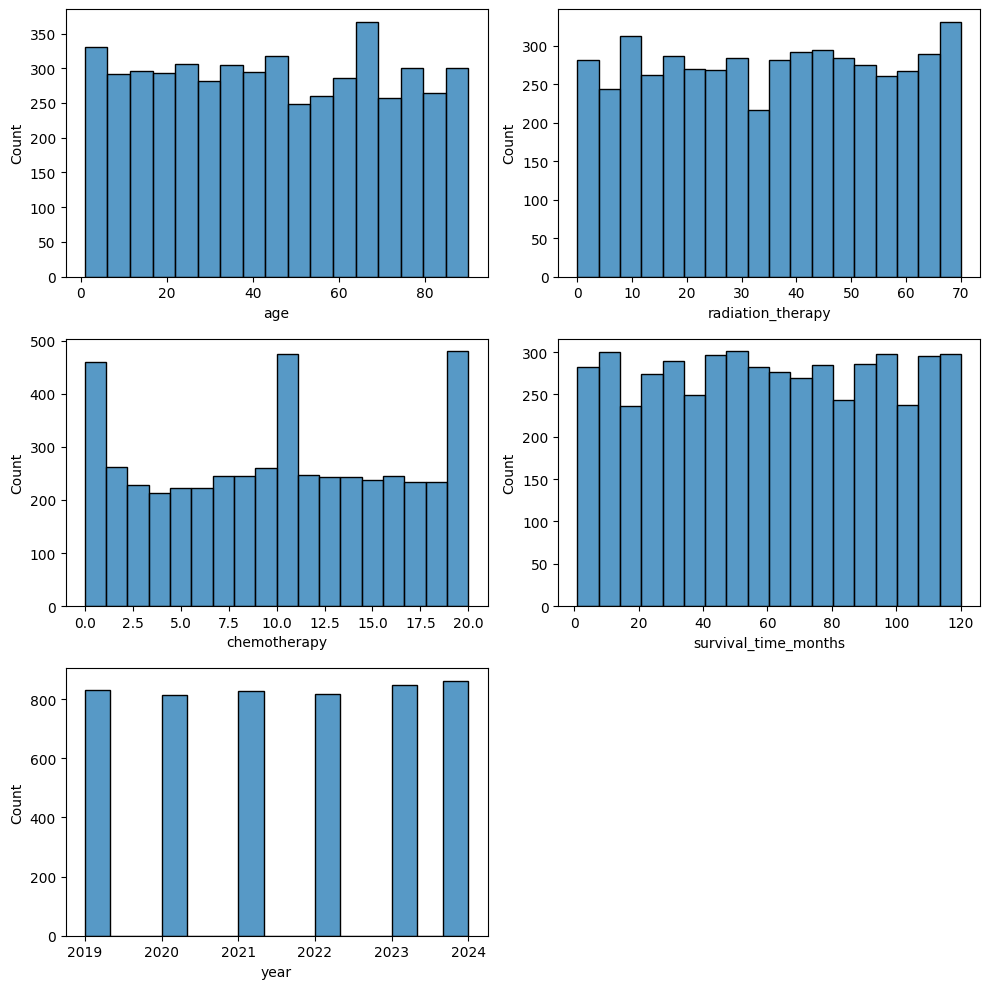

In [20]:

fig, ax = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(data=df, x='age', ax=ax[0, 0])
sns.histplot(data=df, x='radiation_therapy', ax=ax[0, 1])
sns.histplot(data=df, x='chemotherapy', ax=ax[1, 0])
sns.histplot(data=df, x='survival_time_months', ax=ax[1, 1])
sns.histplot(data=df, x='year', ax=ax[2, 0])


ax[2, 1].axis('off')

plt.tight_layout()
plt.show()

3. distribusi jumlah data pada column bertipe karakter

In [21]:
columns_=[ 'gender', 'cancer_type', 'laterality',
          'stage_at_diagnosis', 'treatment_type',
          'outcome_status', 'genetic_markers', 'family_history', 'country',
       ]


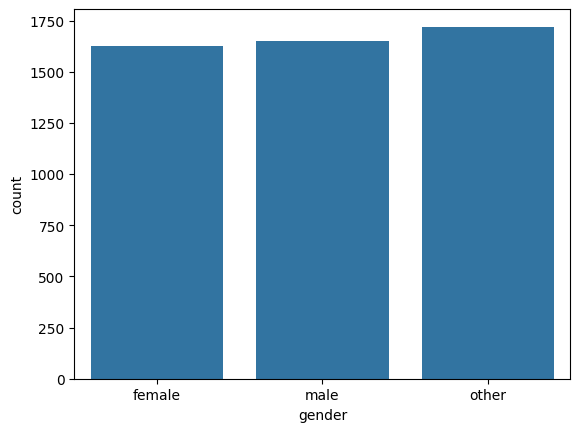

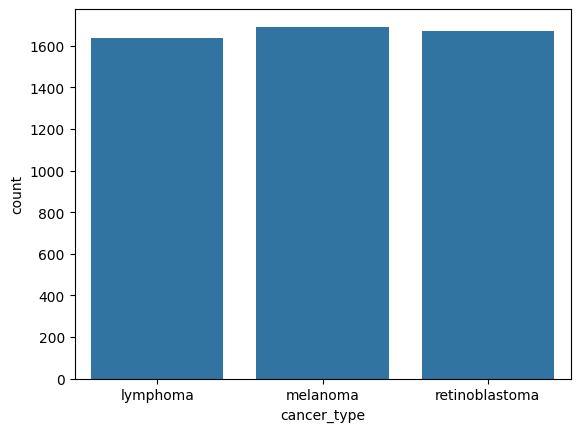

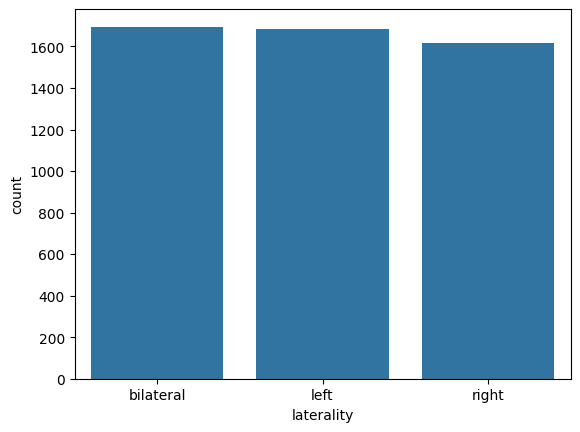

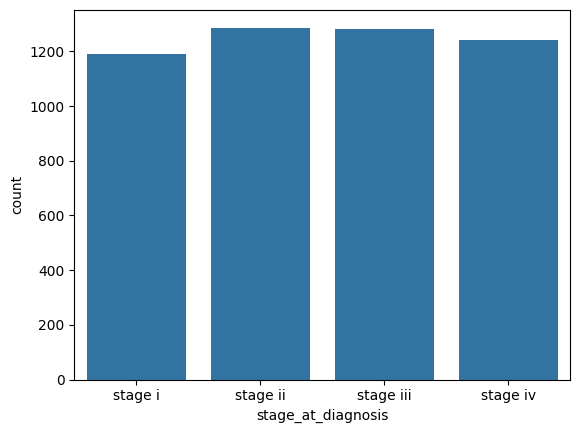

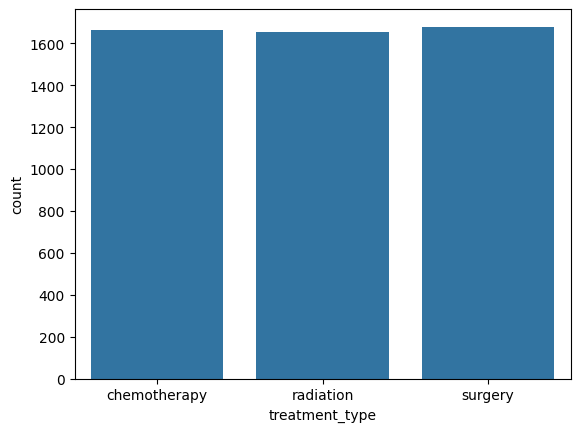

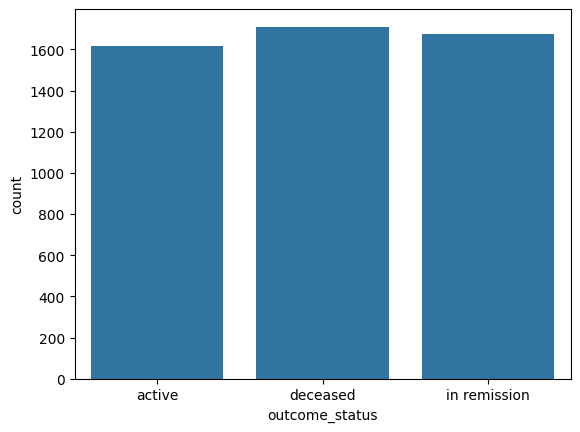

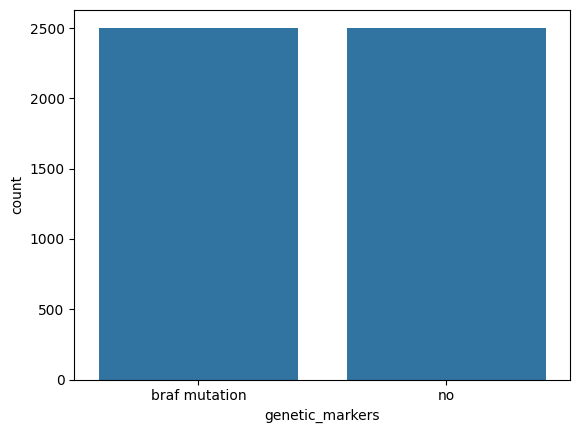

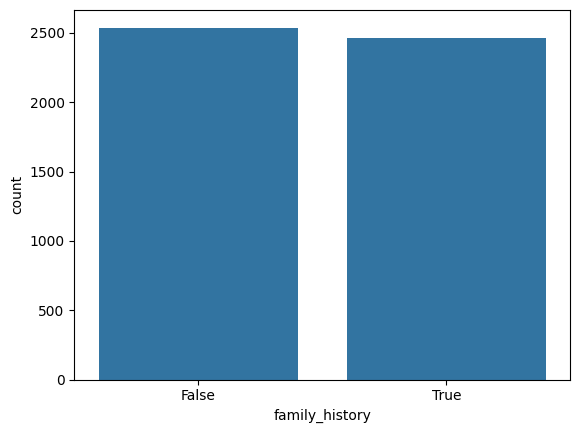

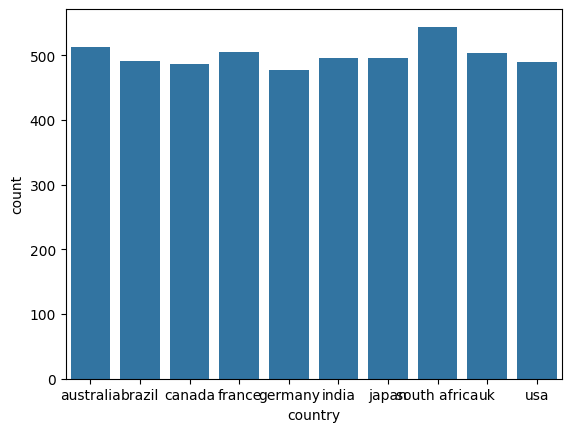

In [22]:
for col in columns_:
    df_group = df.groupby(col).size().reset_index(name='count')
    df_group.columns = [col, 'count']

    sns.barplot(data=df_group, x=col, y='count')
    plt.show()

#### Analisis
1. Dataset terdiri dari 5.000 baris dan 18 kolom.
2. Variabel numerik menunjukkan distribusi yang relatif merata, tanpa perbedaan signifikan pada setiap rentang nilai.
3. Variabel kategorikal (seperti gender, dll.) juga memiliki proporsi yang relatif seimbang antar kategori.
#### Kesimpulan
1. Jumlah pasien kanker mata cenderung stabil, tidak menunjukkan tren peningkatan atau penurunan yang signifikan.
2. Faktor-faktor seperti usia, gender, dan variabel lainnya dalam dataset ini tampak memiliki kontribusi yang relatif seimbang terhadap kemungkinan terkena kanker.
3. Kemungkinan terdapat faktor lain di luar dataset yang lebih berpengaruh (misalnya: faktor genetik, lingkungan, atau gaya hidup) yang belum tercakup dalam data.